# Maritime Speed Prediction — Baseline Models

## Goal
Build and evaluate models predicting **SOG (Speed Over Ground)** as a function of environmental conditions. Then compare two scenarios: *baseline* (no rotor contribution) vs *with rotors*.

## Model hierarchy (per project spec)
| # | Model | Description |
|---|---|---|
| B1 | Constant mean | Predict the voyage mean SOG — naive baseline |
| B2 | Linear regression | `SOG = f(U_wind, H_s)` |
| M1 | XGBoost | `SOG = f(U_wind, H_s, α, currents, ...)` |

## Validation strategy
**Voyage-based split** — training and test sets contain different voyages. This prevents temporal leakage (the model never sees future observations from voyages it was trained on), which matches the real deployment scenario where we predict a new voyage.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import RegularGridInterpolator
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

plt.style.use('seaborn-v0_8-darkgrid')

DATA_PATH = '../data/MasterSet_features.csv'
RESULTS_PATH = '../results/'

## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['Time'])
df = df.sort_values('Time').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Voyages: {df['Voyage_ID'].nunique()}")
print(f"Time range: {df['Time'].min()} → {df['Time'].max()}")
print(f"\nTarget (Speed_kn):")
print(df['Speed_kn'].describe().round(2))

Shape: (125160, 21)
Voyages: 528
Time range: 2023-02-02 00:06:00 → 2026-02-02 07:25:00

Target (Speed_kn):
count    125160.00
mean         11.52
std           2.15
min           5.00
25%          10.10
50%          11.70
75%          12.80
max          20.00
Name: Speed_kn, dtype: float64


## 2. Feature Selection and Voyage-Based Split

Features are grouped into:
- **Core** (spec base model): `True_Wind_Speed_ms`, `H_s`, `alpha_deg`
- **Extended**: add current vector, wave period, gusts

Split: sort voyages chronologically, use the last 20% as test set.

In [ ]:
TARGET = 'Speed_kn'

# Base features (spec model: SOG = f(U_wind, H_s, α))
FEATURES_BASE = ['True_Wind_Speed_ms', 'H_s', 'alpha_deg']

# Extended features
FEATURES_EXT = [
    'True_Wind_Speed_ms', 'H_s', 'alpha_deg', 'alpha_abs_deg',
    'u10', 'v10', 'uo', 'vo', 'mwp', 'fg10',
]

# Voyage-based chronological split: last 20% of voyages → test
voyage_order = (
    df.groupby('Voyage_ID')['Time'].min()
    .sort_values()
    .index.tolist()
)
split_idx = int(len(voyage_order) * 0.8)
train_voyages = set(voyage_order[:split_idx])
test_voyages  = set(voyage_order[split_idx:])

train_mask = df['Voyage_ID'].isin(train_voyages)
test_mask  = df['Voyage_ID'].isin(test_voyages)

df_train = df[train_mask].dropna(subset=FEATURES_EXT + [TARGET])
df_test  = df[test_mask].dropna(subset=FEATURES_EXT + [TARGET])

print(f"Train:{len(df_train):,} rows, {len(train_voyages)} voyages")
print(f"Test: {len(df_test):,} rows, {len(test_voyages)} voyages")
print(f"Train time: {df_train['Time'].min().date()} → {df_train['Time'].max().date()}")
print(f"Test time: {df_test['Time'].min().date()} → {df_test['Time'].max().date()}")

Train: 89,190 rows, 422 voyages
Test:  35,970 rows, 106 voyages
Train time: 2023-02-02 → 2025-05-23
Test  time: 2025-05-23 → 2026-02-02


## 3. Baseline 1 — Constant Mean Speed

Predicts the training-set mean SOG for every test observation. Sets the floor for model performance.

In [ ]:
y_train = df_train[TARGET].values
y_test  = df_test[TARGET].values

mean_speed = y_train.mean()
y_pred_b1  = np.full_like(y_test, mean_speed)

results = {}

def eval_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    within_1kn = np.mean(np.abs(y_pred - y_true) <= 1.0) * 100
    results[name] = dict(MAE=mae, RMSE=rmse, R2=r2, within_1kn=within_1kn)
    print(f"{name:30s}  MAE={mae:.3f} kn  RMSE={rmse:.3f} kn  R²={r2:.3f}  within±1kn={within_1kn:.1f}%")

eval_metrics(y_test, y_pred_b1, 'B1: Constant mean')
print(f"(mean speed = {mean_speed:.2f} kn)")

B1: Constant mean               MAE=1.397 kn  RMSE=1.906 kn  R²=-0.002  within±1kn=49.1%
  (mean speed = 11.54 kn)


## 4. Baseline 2 — Linear Regression (wind + wave)

Per spec: simple linear regression with wind speed and wave height.

In [ ]:
scaler_b2 = StandardScaler()
X_train_b2 = scaler_b2.fit_transform(df_train[FEATURES_BASE])
X_test_b2  = scaler_b2.transform(df_test[FEATURES_BASE])

lr = LinearRegression()
lr.fit(X_train_b2, y_train)
y_pred_b2 = lr.predict(X_test_b2)

eval_metrics(y_test, y_pred_b2, 'B2: Linear (wind+wave+α)')

print("\nLinear regression coefficients:")
for feat, coef in zip(FEATURES_BASE, lr.coef_):
    print(f"{feat:25s}: {coef:+.4f}")
print(f"{'intercept':25s}: {lr.intercept_:+.4f}")

B2: Linear (wind+wave+α)        MAE=1.376 kn  RMSE=1.871 kn  R²=0.035  within±1kn=49.7%

Linear regression coefficients:
  True_Wind_Speed_ms       : +0.2302
  H_s                      : -0.0309
  alpha_deg                : +0.0099
  intercept                : +11.5448


## 5. Main Model — XGBoost (extended features)

In [6]:
scaler_xgb = StandardScaler()
X_train_xgb = scaler_xgb.fit_transform(df_train[FEATURES_EXT])
X_test_xgb  = scaler_xgb.transform(df_test[FEATURES_EXT])

model_xgb = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_xgb.fit(X_train_xgb, y_train)
y_pred_xgb = model_xgb.predict(X_test_xgb)

eval_metrics(y_test, y_pred_xgb, 'M1: XGBoost (extended)')

M1: XGBoost (extended)          MAE=1.471 kn  RMSE=1.902 kn  R²=0.003  within±1kn=42.3%


## 6. Model Comparison

In [7]:
summary = pd.DataFrame(results).T.round(3)
summary.index.name = 'Model'
print(summary.to_string())

                            MAE   RMSE     R2  within_1kn
Model                                                    
B1: Constant mean         1.397  1.906 -0.002      49.088
B2: Linear (wind+wave+α)  1.376  1.871  0.035      49.666
M1: XGBoost (extended)    1.471  1.902  0.003      42.299


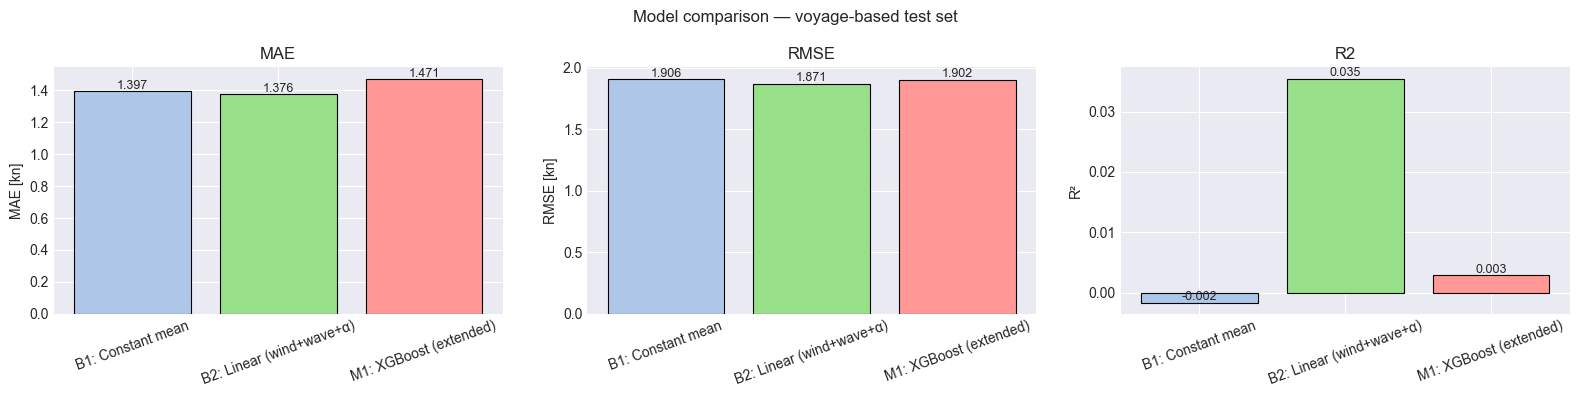

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_names = list(results.keys())
colors = ['#aec7e8', '#98df8a', '#ff9896']

for ax, metric, ylabel in zip(
    axes,
    ['MAE', 'RMSE', 'R2'],
    ['MAE [kn]', 'RMSE [kn]', 'R²']
):
    vals = [results[m][metric] for m in model_names]
    ax.bar(model_names, vals, color=colors, edgecolor='black', linewidth=0.8)
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals)*0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Model comparison — voyage-based test set', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Predicted vs Actual (XGBoost)

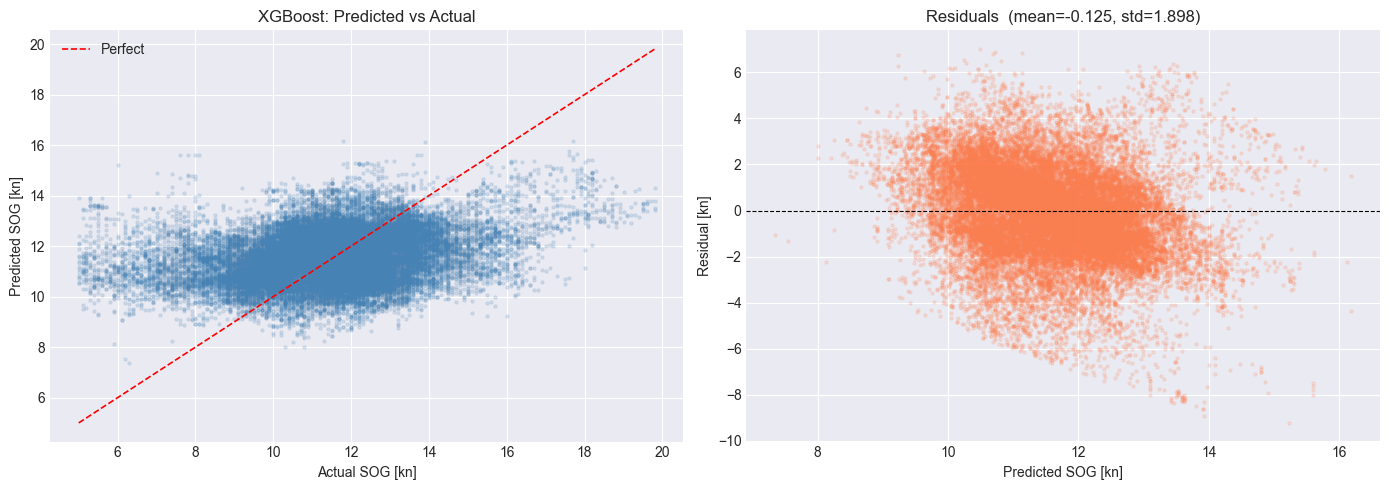

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# predicted vs actual
axes[0].scatter(y_test, y_pred_xgb, alpha=0.15, s=5, color='steelblue')
lims = [min(y_test.min(), y_pred_xgb.min()), max(y_test.max(), y_pred_xgb.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.2, label='Perfect')
axes[0].set_xlabel('Actual SOG [kn]')
axes[0].set_ylabel('Predicted SOG [kn]')
axes[0].set_title('XGBoost: predicted vs actual')
axes[0].legend()

# residuals
residuals = y_test - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuals, alpha=0.15, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Predicted SOG [kn]')
axes[1].set_ylabel('Residual [kn]')
axes[1].set_title(f'Residuals (mean={residuals.mean():.3f}, std={residuals.std():.3f})')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance

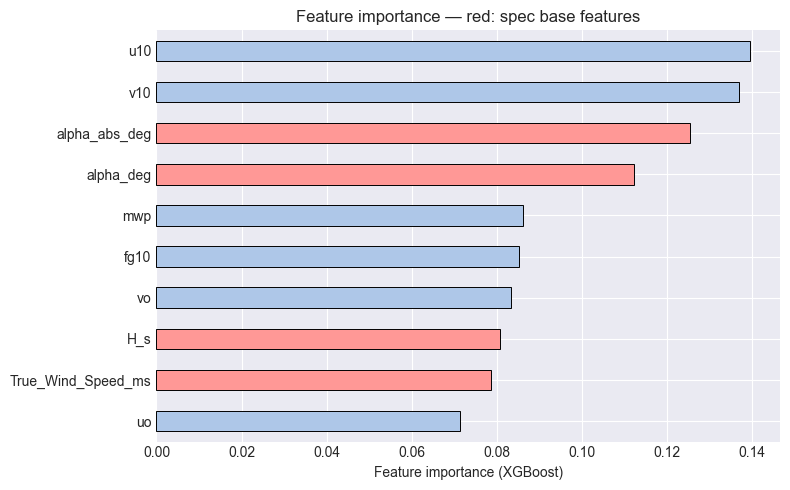


Core spec features (U_wind, H_s, α) cumulative importance: 0.272


In [11]:
importances = pd.Series(model_xgb.feature_importances_, index=FEATURES_EXT).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_imp = ['#ff9896' if f in ('True_Wind_Speed_ms', 'H_s', 'alpha_deg', 'alpha_abs_deg')
              else '#aec7e8' for f in importances.index]
importances.plot.barh(ax=ax, color=colors_imp, edgecolor='black', linewidth=0.7)
ax.set_xlabel('Feature importance (XGBoost)')
ax.set_title('Feature importance — red: spec base features')
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCore spec features (U_wind, H_s, α) cumulative importance:",
      f"{importances[['True_Wind_Speed_ms','H_s','alpha_deg']].sum():.3f}")

## 9. Rotor What-If Scenario

Using the rotor polar diagram (from `feature_engineering.ipynb`), we estimate the expected rotor power contribution for each test observation. Since the training data was collected with rotors operating, we use this as the *with-rotors* baseline. The *without-rotors* counterfactual subtracts the estimated rotor power, converted to a speed equivalent.

**Speed conversion:** A rough approximation at ~12 kn is `ΔV [kn] ≈ P_rotor [kW] / 200`. This assumes a linear thrust-speed relationship around the operating point and is suitable for planning-level scenario comparison.

In [ ]:
# rotor polar diagram (same as feature_engineering.ipynb)
WIND_SPEEDS = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
WIND_ANGLES = np.array([0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180])
POWER_TABLE = np.array([
    [  0,   3,  10,  14,  16,  14,  12,   7,   3,   1,   0],
    [ -2,   6,  22,  38,  44,  42,  38,  22,   9,   3,   0],
    [ -5,  12,  45,  78,  90,  87,  78,  46,  19,   7,   0],
    [ -8,  20,  75, 128, 148, 144, 130,  76,  32,  11,   0],
    [-12,  30, 110, 186, 215, 210, 188, 110,  46,  16,   0],
    [-16,  42, 152, 256, 297, 290, 260, 152,  64,  22,   0],
    [-21,  56, 200, 335, 390, 380, 340, 199,  83,  29,   0],
    [-27,  72, 254, 425, 496, 484, 433, 254, 106,  37,   0],
    [-33,  90, 315, 526, 614, 599, 537, 314, 131,  46,   0],
    [-40, 110, 382, 638, 745, 727, 651, 381, 159,  55,   0],
    [-48, 132, 456, 762, 890, 868, 778, 455, 190,  66,   0],
])

_interp = RegularGridInterpolator(
    (WIND_SPEEDS, WIND_ANGLES), POWER_TABLE, method='linear',
    bounds_error=False, fill_value=None
)

def rotor_power_kw(wind_ms, alpha_abs):
    ws = np.clip(np.asarray(wind_ms, float), WIND_SPEEDS.min(), WIND_SPEEDS.max())
    wa = np.clip(np.asarray(alpha_abs, float), WIND_ANGLES.min(), WIND_ANGLES.max())
    return _interp(np.column_stack([ws.ravel(), wa.ravel()])).reshape(ws.shape)


KW_PER_KN = 200.0  # rough conversion: 200 kW ≈ 1 kn at operating point

# rotor contribution on test set
p_rotor = rotor_power_kw(
    df_test['True_Wind_Speed_ms'].values,
    df_test['alpha_abs_deg'].values
)

# rotor active: positive power, H_s ≤ 6, wind ≤ 42
active = (p_rotor > 0) & (df_test['H_s'].values <= 6.0) & (df_test['True_Wind_Speed_ms'].values <= 42.0)

delta_v = np.where(active, p_rotor / KW_PER_KN, 0.0)

# with-rotor prediction = XGBoost prediction (trained on data with rotors operating)
# without-rotor counterfactual = subtract the estimated rotor contribution
y_pred_with_rotor    = y_pred_xgb
y_pred_without_rotor = y_pred_xgb - delta_v

print(f"Rotor active: {active.sum():,} / {len(active):,} rows ({active.mean()*100:.1f}%)")
print(f"Mean rotor power when active: {p_rotor[active].mean():.1f} kW")
print(f"Mean delta_SOG when active: {delta_v[active].mean():.3f} kn")
print(f"Overall mean delta_SOG: {delta_v.mean():.3f} kn")

Rotor active: 35,288 / 35,970 rows (98.1%)
Mean rotor power when active: 41.1 kW
Mean ΔSOG when active: 0.205 kn
Overall mean ΔSOG: 0.201 kn


In [ ]:
# per-voyage rotor benefit
df_test_copy = df_test.copy()
df_test_copy['pred_with_rotor'] = y_pred_with_rotor
df_test_copy['pred_without_rotor'] = y_pred_without_rotor
df_test_copy['delta_v'] = delta_v
df_test_copy['rotor_active'] = active.astype(int)

voyage_summary = df_test_copy.groupby('Voyage_ID').agg(
    n_points = ('Speed_kn', 'count'),
    mean_sog_actual = ('Speed_kn', 'mean'),
    mean_sog_pred = ('pred_with_rotor', 'mean'),
    mean_sog_no_rot = ('pred_without_rotor', 'mean'),
    rotor_active_pct= ('rotor_active', 'mean'),
    mean_delta_v = ('delta_v', 'mean'),
).round(3)

voyage_summary['delta_v_kn'] = (voyage_summary['mean_sog_pred'] - voyage_summary['mean_sog_no_rot']).round(3)

print("Per-voyage rotor scenario summary (test set):")
print(voyage_summary.sort_values('mean_delta_v', ascending=False).head(10).to_string())

Per-voyage rotor scenario summary (test set):
           n_points  mean_sog_actual  mean_sog_pred  mean_sog_no_rot  rotor_active_pct  mean_delta_v  delta_v_kn
Voyage_ID                                                                                                       
501             144           12.875         11.803           10.625             1.000         1.178       1.178
488             127           14.012         13.029           12.254             1.000         0.774       0.775
456             513           11.491         12.276           11.535             1.000         0.741       0.741
520             330           11.833         11.365           10.689             0.988         0.676       0.676
474             497           11.768         12.169           11.591             0.998         0.578       0.578
525             953           11.823         11.603           11.070             0.999         0.533       0.533
521             145           12.150         13.57

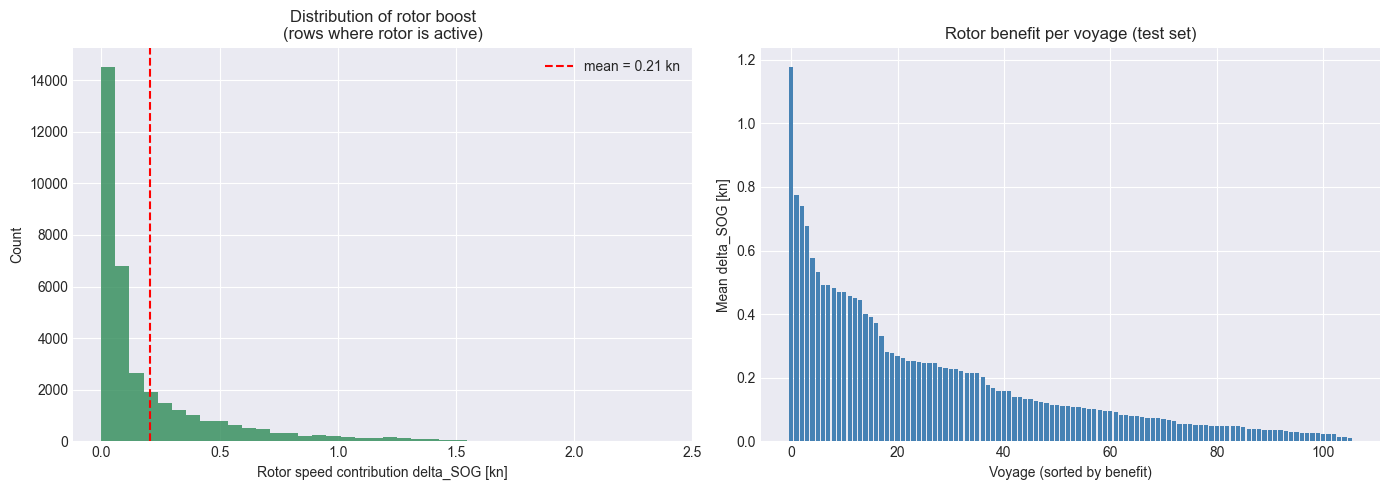

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of ΔSOG
axes[0].hist(delta_v[active], bins=40, color='seagreen', edgecolor='none', alpha=0.8)
axes[0].axvline(delta_v[active].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'mean = {delta_v[active].mean():.2f} kn')
axes[0].set_xlabel('Rotor speed contribution delta_SOG [kn]')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of rotor boost\n(rows where rotor is active)')
axes[0].legend()

# Per-voyage mean delta_SOG
dvs = voyage_summary['mean_delta_v'].sort_values(ascending=False)
axes[1].bar(range(len(dvs)), dvs.values, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Voyage (sorted by benefit)')
axes[1].set_ylabel('Mean delta_SOG [kn]')
axes[1].set_title('Rotor benefit per voyage (test set)')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Weather Window Analysis

**Definition (spec):** A weather window is a contiguous time interval where:
- Predicted SOG ≥ threshold (e.g. 10 kn)
- H_s ≤ threshold (e.g. 3 m)

We compare window counts and lengths between the baseline (no rotor) and with-rotor scenarios.

In [15]:
SOG_THRESHOLD = 10.0   # minimum speed [kn]
HS_THRESHOLD  = 3.0    # maximum wave height [m]

def count_windows(sog_series, hs_series, sog_min, hs_max):
    """Count contiguous windows meeting both conditions."""
    in_window = (sog_series >= sog_min) & (hs_series <= hs_max)
    # Count transitions False→True
    starts = np.sum(~in_window.values[:-1] & in_window.values[1:])
    if in_window.values[0]:
        starts += 1
    total_points = in_window.sum()
    return int(starts), int(total_points)


hs_test = df_test['H_s'].values

n_win_base, pts_base = count_windows(
    pd.Series(y_pred_without_rotor), pd.Series(hs_test), SOG_THRESHOLD, HS_THRESHOLD)
n_win_rot,  pts_rot  = count_windows(
    pd.Series(y_pred_with_rotor),    pd.Series(hs_test), SOG_THRESHOLD, HS_THRESHOLD)

total = len(y_pred_xgb)
print(f"Weather window definition: SOG ≥ {SOG_THRESHOLD} kn  AND  H_s ≤ {HS_THRESHOLD} m")
print(f"")
print(f"{'Scenario':<25} {'Windows':>10} {'Points in window':>18} {'Coverage':>10}")
print("-" * 65)
print(f"{'Without rotor':<25} {n_win_base:>10} {pts_base:>18,} {pts_base/total*100:>9.1f}%")
print(f"{'With rotor':<25} {n_win_rot:>10} {pts_rot:>18,} {pts_rot/total*100:>9.1f}%")
print(f"{'Delta':<25} {n_win_rot-n_win_base:>+10} {pts_rot-pts_base:>+18,} {(pts_rot-pts_base)/total*100:>+9.1f}%")

Weather window definition: SOG ≥ 10.0 kn  AND  H_s ≤ 3.0 m

Scenario                     Windows   Points in window   Coverage
-----------------------------------------------------------------
Without rotor                    460             31,666      88.0%
With rotor                       379             32,485      90.3%
Delta                            -81               +819      +2.3%


## 11. Summary

In [18]:
print("=" * 70)
print("MARITIME SPEED PREDICTION — SUMMARY")
print("=" * 70)
print(f"Target: Speed_kn (SOG)")
print(f"Train: {len(train_voyages)} voyages ({len(df_train):,} rows)")
print(f"Test: {len(test_voyages)} voyages ({len(df_test):,} rows) [chronological split]")
print()
print(f"{'Model':<30} {'MAE [kn]':>10} {'RMSE [kn]':>10} {'R²':>8}")
print("-" * 60)
for name, m in results.items():
    print(f"{name:<30} {m['MAE']:>10.3f} {m['RMSE']:>10.3f} {m['R2']:>8.3f}")
print()
print(f"Rotor active (test set): {active.mean()*100:.1f}% of observations")
print(f"Mean rotor delta_SOG (active): {delta_v[active].mean():.3f} kn")
print(f"Weather window coverage: {pts_base/total*100:.1f}% → {pts_rot/total*100:.1f}% (with rotors)")
print("=" * 70)

MARITIME SPEED PREDICTION — SUMMARY
Target: Speed_kn (SOG)
Train: 422 voyages (89,190 rows)
Test: 106 voyages (35,970 rows) [chronological split]

Model                            MAE [kn]  RMSE [kn]       R²
------------------------------------------------------------
B1: Constant mean                   1.397      1.906   -0.002
B2: Linear (wind+wave+α)            1.376      1.871    0.035
M1: XGBoost (extended)              1.471      1.902    0.003

Rotor active (test set): 98.1% of observations
Mean rotor delta_SOG (active): 0.205 kn
Weather window coverage: 88.0% → 90.3% (with rotors)


## 12.Trajectory visualization

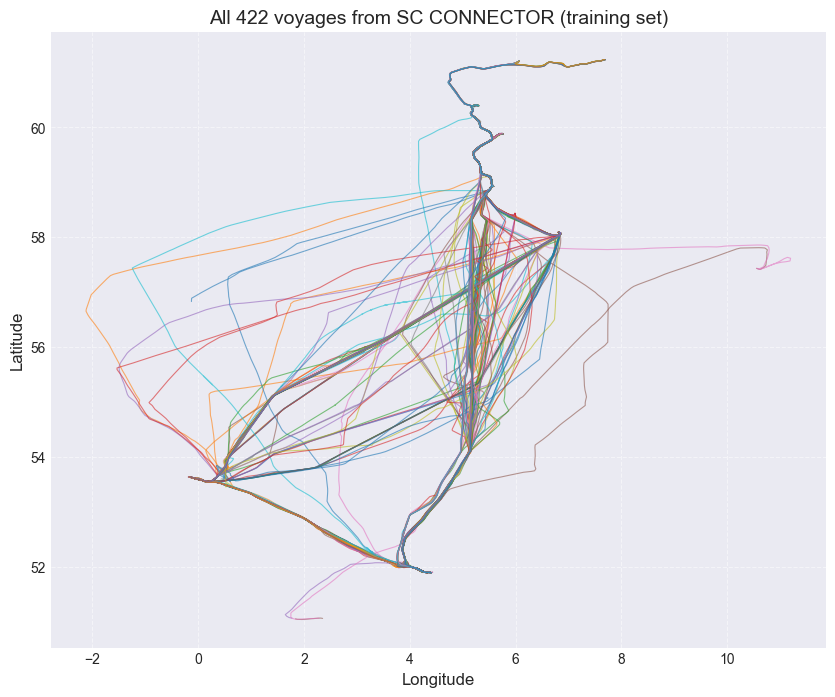

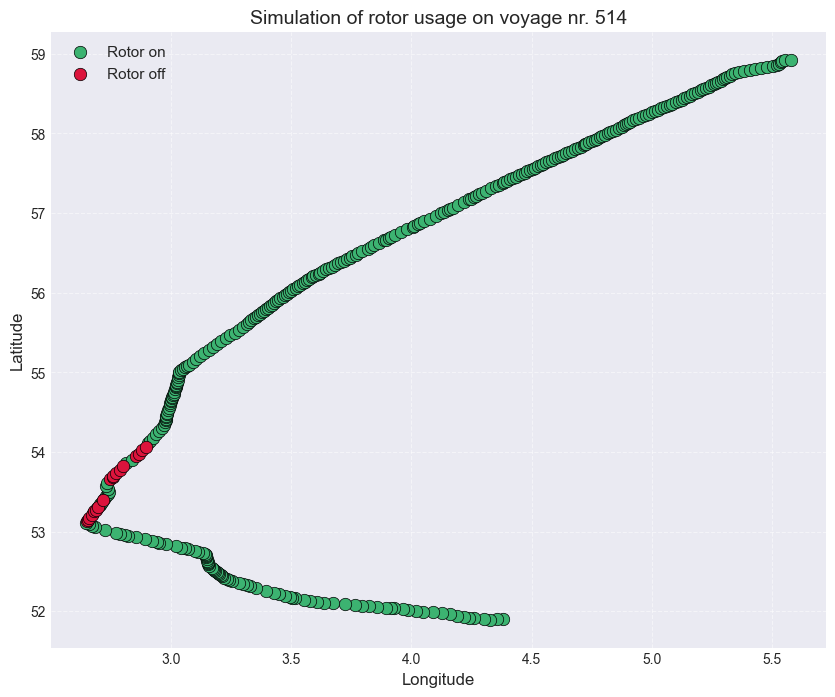

In [ ]:
# map 1 - are trips overlapping? 
plt.figure(figsize=(10, 8))
# all trips to see repetability (from train set)
for v_id in df_train['Voyage_ID'].unique()[:422]:
    v_data = df_train[df_train['Voyage_ID'] == v_id]
    plt.plot(v_data['Lon'], v_data['Lat'], linewidth=0.8, alpha=0.6)

plt.title("All 422 voyages from SC CONNECTOR (training set)", fontsize=14)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(RESULTS_PATH + 'all_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()


# map 2 - when the rotor is on? 
voyage = 514
v_data = df_test_copy[df_test_copy['Voyage_ID'] == voyage]

plt.figure(figsize=(10, 8))

# whole trajectory
plt.plot(v_data['Lon'], v_data['Lat'], color='gray', linestyle='--', linewidth=1.5, zorder=1)

# green points = rotor on
rotor_on = v_data[v_data['rotor_active'] == 1]
plt.scatter(rotor_on['Lon'], rotor_on['Lat'], c='mediumseagreen', s=80, edgecolor='black', linewidth=0.5, label='Rotor on', zorder=2)

# red points = rotor off
rotor_off = v_data[v_data['rotor_active'] == 0]
if not rotor_off.empty:
    plt.scatter(rotor_off['Lon'], rotor_off['Lat'], c='crimson', s=80, edgecolor='black', linewidth=0.5, label='Rotor off', zorder=3)

plt.title(f"Simulation of rotor usage on voyage nr. {voyage}", fontsize=14)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(RESULTS_PATH + f'rotor_voyage_{voyage}.png', dpi=150, bbox_inches='tight')
plt.show()